In [2]:
#1.导入库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
plt.rcParams['font.sans-serif']='SimHei'

#2.导入数据
df=pd.read_csv('F:/Data Analysis/house_sales.csv')

#3.数据概览
print('总记录数:',len(df))
print('字段数量:',len(df.columns))
df.head(5)
df.info

#4.数据清洗
df.drop(columns='origin_url',inplace=True)
df.isna().sum()
df.dropna(inplace=True)
df.duplicated().sum()
df.drop_duplicates(inplace=True)
#面积的数据类型转换
df['area']=df['area'].str.replace('㎡','').astype(float)
#价格的数据类型转换
df['price']=df['price'].str.replace('万','').astype(float)
#朝向的数据类型转换
df['toward']=df['toward'].astype('category')
#单价的数据类型转换
df['unit']=df['unit'].str.replace('元/㎡','').astype(float)
#年份的处理
df['year']=df['year'].str.replace('年建','').astype(int)
df.head()
#房屋面积的异常处理
df=df[(df['area']<600) & (df['area']>20)]
#房屋售价的异常处理
Q1=df['price'].quantile(0.25)
Q3=df['price'].quantile(0.75)
IQR=Q3-Q1
low_price=Q1-1.5*IQR
high_price=Q3+1.5*IQR
df=df[(df['price']>low_price) & (df['price']<high_price)]

总记录数: 106118
字段数量: 12


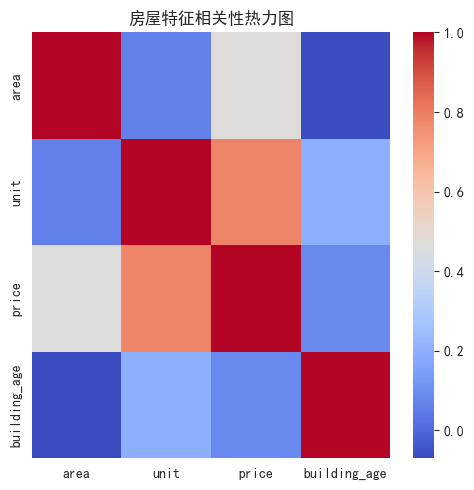

In [43]:
#5.新数据特征构造
#地区district
df['district']=df['address'].str.split('-').str[0].astype('category')
#楼层的类型floor_type
def func1(str1):
    if pd.isna(str1):
        return '未知'
    elif '低' in str1:
        return '低楼层'
    elif '中' in str1:
        return '中楼层'
    elif '高' in str1:
        return '高楼层'
    else:
        return '未知'
df['floor_type']=df['floor'].apply(func1)
#是否是直辖市zxs
df['zxs']=df['city'].apply(lambda x:1 if x in ['北京','上海','天津','重庆'] else 0)
#卧室的数量bedrooms
df['bedrooms']=df['rooms'].str.split('室').str[0].astype(int)
#客厅的数量living rooms
df['living rooms']=df['rooms'].str.extract(r'(\d+)厅').astype(int)
#楼龄building_age
df['building_age']=2026-df['year']
#价格的分段price_labels
df['price_labels']=pd.cut(df['price'],bins=4,labels=['低价','中价','高价','豪华'])
#6.问题分析及可视化
'''问题编号:A1
问题:哪些变量最影响房价?面积、楼层、房间数哪个影响更大?
分析主题:特征相关性
分析目标:了解房屋各特征对房价的线性影响
分组字段:无
指标/方法:皮尔逊相关系数
'''
#选择数值型特征
A1=df[['area','unit','price','building_age']].corr()
#对房价影响最大因素的排序
A1['price'].sort_values(ascending=False)[1:]
#相关性的热力图
plt.figure(figsize=(5,5))
sns.heatmap(A1,cmap='coolwarm')
plt.title('房屋特征相关性热力图')
plt.tight_layout()
plt.show()

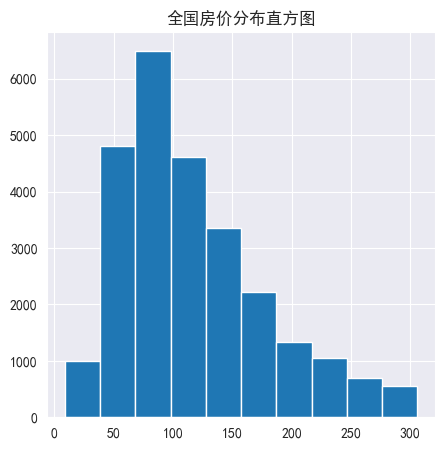

<Axes: xlabel='price', ylabel='Count'>

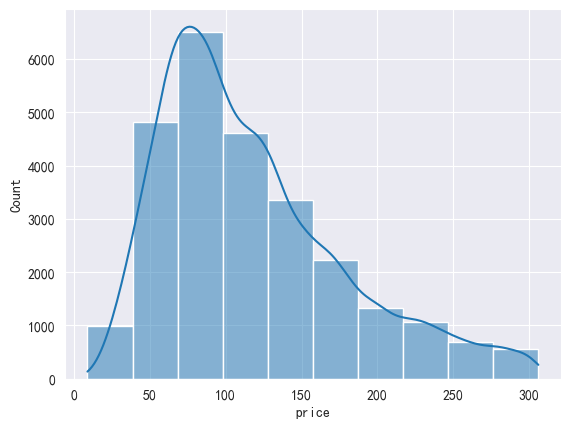

In [4]:
#房价分布直方图
plt.figure(figsize=(5,5))
plt.hist(df['price'],bins=10)
plt.title('全国房价分布直方图')
plt.show()
sns.histplot(data=df,x='price',bins=10,kde=True)

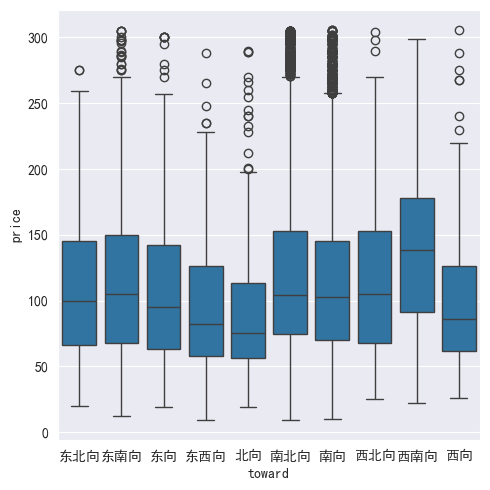

In [9]:
'''
问题编号:A3
问题:南北向是否真比单一朝向贵?贵多少?
分析主题:朝向溢价
分析目标:评估不同朝向的价格差异
分组字段:toward
方法:方差分析/多重比较
'''
df.groupby('toward').agg({
    'price':['mean','median'],
    'unit':'mean'
})
#数据可视化
plt.figure(figsize=(5,5))
sns.boxplot(data=df,x='toward',y='price')
plt.tight_layout()